In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from astropy.cosmology import Planck18 as cosmo
from astropy import units as u, constants as c
import astropy.cosmology.units as cu

In [2]:
meta = pd.read_csv("ecle-metadata.csv")
meta

,name,ra,ra_unit,dec,dec_unit,coord_bibcode,ecl_discovery_date,discovery_date,discovery_date_format,discovery_date_bibcode,redshift,redshift_bibcode,classification,classification_bibcode,radio_data,radio_data_comment,otter,otter_comments,comment
0,2019qiz,04:46:37.880,hour,-10:13:34.90,degree,2019TNSTR1857....1F,2020-12-15,2458745.9998032,JD,2019TNSTR1857....1F,0.015100,2019TNSTR1857....1F,TDE,2019TNSCR1921....1S,True,"Kate (very good radio dataset, still need to a...",True,good uvoir dataset,Uploader:Noah Franz | Email: nfranz@arizona.edu
1,SDSS_J0748,07:48:20.6668,hour,+47:12:14.2648,degree,2024MNRAS.535.1095C,2004-02-20,2004-02-20,iso,2024MNRAS.528.7076C,0.061600,2024MNRAS.528.7076C,TDE,2024MNRAS.528.7076C,True,"Kate, VLASS",True,some xray data is available,Uploader:Noah Franz | Email: nfranz@arizona.edu
2,SDSS_J0807,08:07:27.3157,hour,+14:05:37.0892,degree,2024MNRAS.535.1095C,2005-11-08,2005-11-08,iso,2024MNRAS.528.7076C,0.073800,2024MNRAS.528.7076C,AGN,2024MNRAS.528.7076C,True,VLASS,False,NaN,Uploader:Noah Franz | Email: nfranz@arizona.edu
3,SDSS_J0938,09:38:01.6376,hour,+13:53:17.0423,degree,2024MNRAS.535.1095C,2006-12-23,2006-12-23,iso,2024MNRAS.528.7076C,0.101000,2024MNRAS.528.7076C,AGN,2024MNRAS.528.7076C,True,"Kate, VLASS",False,NaN,Uploader:Noah Franz | Email: nfranz@arizona.edu
4,SDSS_J0952,09:52:09.5629,hour,+21:43:13.2979,degree,2024MNRAS.535.1095C,2005-12-30,2005-12-30,iso,2024MNRAS.528.7076C,0.079500,2024MNRAS.528.7076C,TDE,2024MNRAS.528.7076C,True,"Kate, VLASS",True,some xray data is available,Uploader:Noah Franz | Email: nfranz@arizona.edu
5,SDSS_J1055,10:55:26.4177,hour,+56:37:13.1010,degree,2024MNRAS.535.1095C,2002-04-09,2002-04-09,iso,2024MNRAS.528.7076C,0.074000,2024MNRAS.528.7076C,AGN,2024MNRAS.528.7076C,True,"Kate, VLASS",False,NaN,Uploader:Noah Franz | Email: nfranz@arizona.edu
6,SDSS_J1207,12:07:19.8102,hour,+24:11:55.8789,degree,2024MNRAS.535.1095C,2008-01-19,2008-01-19,iso,2024MNRAS.528.7076C,0.050300,2024MNRAS.528.7076C,AGN,2024MNRAS.528.7076C,True,VLASS,False,NaN,Uploader:Noah Franz | Email: nfranz@arizona.edu
7,SDSS_J1241,12:41:34.2561,hour,+44:26:39.2636,degree,2024MNRAS.535.1095C,2004-02-27,2004-02-27,iso,2024MNRAS.528.7076C,0.041900,2024MNRAS.528.7076C,TDE,2024MNRAS.528.7076C,True,"Kate, VLASS, 4 other observations from other p...",False,NaN,Uploader:Noah Franz | Email: nfranz@arizona.edu
8,SDSS_J1247,12:47:26.3719,hour,+07:05:25.0809,degree,2024MNRAS.535.1095C,2006-05-21,2006-05-21,iso,2024MNRAS.528.7076C,0.104000,2024MNRAS.528.7076C,AGN,2024MNRAS.528.7076C,True,VLASS,False,NaN,Uploader:Noah Franz | Email: nfranz@arizona.edu
9,SDSS_J1342,13:42:44.4150,hour,+05:30:56.1451,degree,2024MNRAS.535.1095C,2002-04-09,2002-04-09,iso,2024MNRAS.528.7076C,0.036500,2024MNRAS.528.7076C,TDE,2024MNRAS.528.7076C,True,"Kate, VLASS",True,WISE data from Wang+18,Uploader:Noah Franz | Email: nfranz@arizona.edu


In [5]:
def redshift_limit(flux, lum):
    lum_dist = np.sqrt(lum / (4*np.pi*flux)).to(u.Mpc)
    return lum_dist.to(cu.redshift, cu.redshift_distance(cosmo, kind="luminosity"))

In [40]:
vlass_flux_limit = 500*u.uJy * 5*u.GHz
newtownian_outflow_luminosity = 1e38*u.erg/u.s
relativistic_outflow_luminosity = 5e40*u.erg/u.s
off_axis_jet_luminosity = 1e39*u.erg/u.s

newtownian_redshift_limit = redshift_limit(vlass_flux_limit, newtownian_outflow_luminosity)
relativistic_redshift_limit = redshift_limit(vlass_flux_limit, relativistic_outflow_luminosity)
off_axis_jet_redshift_limit = redshift_limit(vlass_flux_limit, off_axis_jet_luminosity)

print(rf"VLASS can detect newtownian outflows at $z \lesssim {newtownian_redshift_limit.value:.2f}$")
print(rf"VLASS can detect relativistic outflows at $z \lesssim {relativistic_redshift_limit.value:.2f}$")
print(rf"VLASS can detect relativistic outflows at $z \lesssim {off_axis_jet_redshift_limit.value:.2f}$")

VLASS can detect newtownian outflows at $z \lesssim 0.04$
VLASS can detect relativistic outflows at $z \lesssim 0.66$
VLASS can detect relativistic outflows at $z \lesssim 0.12$


In [41]:
meta[meta.redshift < newtownian_redshift_limit]

,name,ra,ra_unit,dec,dec_unit,coord_bibcode,ecl_discovery_date,discovery_date,discovery_date_format,discovery_date_bibcode,redshift,redshift_bibcode,classification,classification_bibcode,radio_data,radio_data_comment,otter,otter_comments,comment
0,2019qiz,04:46:37.880,hour,-10:13:34.90,degree,2019TNSTR1857....1F,2020-12-15,2458745.9998032,JD,2019TNSTR1857....1F,0.015100,2019TNSTR1857....1F,TDE,2019TNSCR1921....1S,True,"Kate (very good radio dataset, still need to a...",True,good uvoir dataset,Uploader:Noah Franz | Email: nfranz@arizona.edu
9,SDSS_J1342,13:42:44.4150,hour,+05:30:56.1451,degree,2024MNRAS.535.1095C,2002-04-09,2002-04-09,iso,2024MNRAS.528.7076C,0.036500,2024MNRAS.528.7076C,TDE,2024MNRAS.528.7076C,True,"Kate, VLASS",True,WISE data from Wang+18,Uploader:Noah Franz | Email: nfranz@arizona.edu
20,AT2021dms,03:21:24.069,hour,-11:08:45.71,degree,2024MNRAS.528.4775H,2021-08-13,2459266.645706,JD,2021TNSTR.542....1F,0.031102,2024MNRAS.528.4775H,TDE,2024MNRAS.528.4775H,True,VLASS,False,NaN,Uploader:Noah Franz | Email: nfranz@arizona.edu
25,AT2018dyk,15:33:08.015,hour,+44:32:08.20,degree,2018TNSTR.987....1F,2018-08-08,2458269.81,JD,2018TNSTR.987....1F,0.037000,2018TNSCR1182....1H,TDE,2018TNSCR1182....1H,True,VLASS,True,NaN,Uploader:Noah Franz | Email: nfranz@arizona.edu


In [44]:
vla_flux_limit = 30*u.uJy * 5*u.GHz
newtownian_outflow_luminosity = 1e38*u.erg/u.s
relativistic_outflow_luminosity = 5e40*u.erg/u.s
off_axis_jet_luminosity = 1e39*u.erg/u.s

newtownian_redshift_limit = redshift_limit(vla_flux_limit, newtownian_outflow_luminosity)
relativistic_redshift_limit = redshift_limit(vla_flux_limit, relativistic_outflow_luminosity)
off_axis_jet_redshift_limit = redshift_limit(vla_flux_limit, off_axis_jet_luminosity)

print(rf"VLA can detect newtownian outflows at $z \lesssim {newtownian_redshift_limit.value:.2f}$")
print(rf"VLA can detect relativistic outflows at $z \lesssim {relativistic_redshift_limit.value:.2f}$")
print(rf"VLA can detect relativistic outflows at $z \lesssim {off_axis_jet_redshift_limit.value:.2f}$")

VLA can detect newtownian outflows at $z \lesssim 0.15$
VLA can detect relativistic outflows at $z \lesssim 2.08$
VLA can detect relativistic outflows at $z \lesssim 0.42$


In [30]:
meta[(meta.redshift < off_axis_jet_redshift_limit) * (meta.name.str.startswith("SDSS"))]

,name,ra,ra_unit,dec,dec_unit,coord_bibcode,ecl_discovery_date,discovery_date,discovery_date_format,discovery_date_bibcode,redshift,redshift_bibcode,classification,classification_bibcode,radio_data,radio_data_comment,otter,otter_comments,comment
1,SDSS_J0748,07:48:20.6668,hour,+47:12:14.2648,degree,2024MNRAS.535.1095C,2004-02-20,2004-02-20,iso,2024MNRAS.528.7076C,0.0616,2024MNRAS.528.7076C,TDE,2024MNRAS.528.7076C,True,"Kate, VLASS",True,some xray data is available,Uploader:Noah Franz | Email: nfranz@arizona.edu
2,SDSS_J0807,08:07:27.3157,hour,+14:05:37.0892,degree,2024MNRAS.535.1095C,2005-11-08,2005-11-08,iso,2024MNRAS.528.7076C,0.0738,2024MNRAS.528.7076C,AGN,2024MNRAS.528.7076C,True,VLASS,False,NaN,Uploader:Noah Franz | Email: nfranz@arizona.edu
3,SDSS_J0938,09:38:01.6376,hour,+13:53:17.0423,degree,2024MNRAS.535.1095C,2006-12-23,2006-12-23,iso,2024MNRAS.528.7076C,0.1010,2024MNRAS.528.7076C,AGN,2024MNRAS.528.7076C,True,"Kate, VLASS",False,NaN,Uploader:Noah Franz | Email: nfranz@arizona.edu
4,SDSS_J0952,09:52:09.5629,hour,+21:43:13.2979,degree,2024MNRAS.535.1095C,2005-12-30,2005-12-30,iso,2024MNRAS.528.7076C,0.0795,2024MNRAS.528.7076C,TDE,2024MNRAS.528.7076C,True,"Kate, VLASS",True,some xray data is available,Uploader:Noah Franz | Email: nfranz@arizona.edu
5,SDSS_J1055,10:55:26.4177,hour,+56:37:13.1010,degree,2024MNRAS.535.1095C,2002-04-09,2002-04-09,iso,2024MNRAS.528.7076C,0.0740,2024MNRAS.528.7076C,AGN,2024MNRAS.528.7076C,True,"Kate, VLASS",False,NaN,Uploader:Noah Franz | Email: nfranz@arizona.edu
6,SDSS_J1207,12:07:19.8102,hour,+24:11:55.8789,degree,2024MNRAS.535.1095C,2008-01-19,2008-01-19,iso,2024MNRAS.528.7076C,0.0503,2024MNRAS.528.7076C,AGN,2024MNRAS.528.7076C,True,VLASS,False,NaN,Uploader:Noah Franz | Email: nfranz@arizona.edu
7,SDSS_J1241,12:41:34.2561,hour,+44:26:39.2636,degree,2024MNRAS.535.1095C,2004-02-27,2004-02-27,iso,2024MNRAS.528.7076C,0.0419,2024MNRAS.528.7076C,TDE,2024MNRAS.528.7076C,True,"Kate, VLASS, 4 other observations from other p...",False,NaN,Uploader:Noah Franz | Email: nfranz@arizona.edu
8,SDSS_J1247,12:47:26.3719,hour,+07:05:25.0809,degree,2024MNRAS.535.1095C,2006-05-21,2006-05-21,iso,2024MNRAS.528.7076C,0.1040,2024MNRAS.528.7076C,AGN,2024MNRAS.528.7076C,True,VLASS,False,NaN,Uploader:Noah Franz | Email: nfranz@arizona.edu
9,SDSS_J1342,13:42:44.4150,hour,+05:30:56.1451,degree,2024MNRAS.535.1095C,2002-04-09,2002-04-09,iso,2024MNRAS.528.7076C,0.0365,2024MNRAS.528.7076C,TDE,2024MNRAS.528.7076C,True,"Kate, VLASS",True,WISE data from Wang+18,Uploader:Noah Franz | Email: nfranz@arizona.edu
10,SDSS_J1350,13:50:01.4946,hour,+29:16:09.6460,degree,2024MNRAS.535.1095C,2006-04-23,2006-04-23,iso,2024MNRAS.528.7076C,0.0777,2024MNRAS.528.7076C,TDE,2024MNRAS.528.7076C,True,"Kate, VLASS",True,some xray data is available,Uploader:Noah Franz | Email: nfranz@arizona.edu


In [20]:
radio = pd.read_csv("ecle-radio-photometry.csv", comment="#")
# radio = radio[radio.use_this]

radio[radio.source == "VLASS"]

,name,day,date,date_format,array_config,filter,filter_eff,filter_eff_units,flux,flux_err,flux_unit,upperlimit,reducer,source,use_this,comments
105,SDSS_J0952,NaN,60430.044193,mjd,NaN,S,3.0,GHz,0.368530,0.0,mJy,True,VLASS,VLASS,True,NaN
106,SDSS_J0952,NaN,59549.391391,mjd,NaN,S,3.0,GHz,0.357901,0.0,mJy,True,VLASS,VLASS,True,NaN
107,SDSS_J0952,NaN,58592.015904,mjd,NaN,S,3.0,GHz,0.392084,0.0,mJy,True,VLASS,VLASS,True,NaN
108,SDSS_J1207,NaN,59987.332521,mjd,NaN,S,3.0,GHz,0.396179,0.0,mJy,True,VLASS,VLASS,True,NaN
109,SDSS_J1207,NaN,58081.582695,mjd,NaN,S,3.0,GHz,0.366850,0.0,mJy,True,VLASS,VLASS,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,SDSS_J1342,NaN,58595.280753,mjd,NaN,S,3.0,GHz,0.789441,0.0,mJy,True,VLASS,VLASS,True,NaN
174,SDSS_J1342,NaN,60511.125161,mjd,NaN,S,3.0,GHz,0.787560,0.0,mJy,True,VLASS,VLASS,True,NaN
175,SDSS_J1342,NaN,59524.705385,mjd,NaN,S,3.0,GHz,0.766643,0.0,mJy,True,VLASS,VLASS,True,NaN
176,SDSS_J1459,NaN,58587.438523,mjd,NaN,S,3.0,GHz,0.554953,0.0,mJy,True,VLASS,VLASS,True,NaN


In [16]:
meta[meta.redshift < relativistic_redshift_limit]

,name,ra,ra_unit,dec,dec_unit,coord_bibcode,ecl_discovery_date,discovery_date,discovery_date_format,discovery_date_bibcode,redshift,redshift_bibcode,classification,classification_bibcode,radio_data,radio_data_comment,otter,otter_comments,comment
0,2019qiz,04:46:37.880,hour,-10:13:34.90,degree,2019TNSTR1857....1F,2020-12-15,2458745.9998032,JD,2019TNSTR1857....1F,0.015100,2019TNSTR1857....1F,TDE,2019TNSCR1921....1S,True,"Kate (very good radio dataset, still need to a...",True,good uvoir dataset,Uploader:Noah Franz | Email: nfranz@arizona.edu
1,SDSS_J0748,07:48:20.6668,hour,+47:12:14.2648,degree,2024MNRAS.535.1095C,2004-02-20,2004-02-20,iso,2024MNRAS.528.7076C,0.061600,2024MNRAS.528.7076C,TDE,2024MNRAS.528.7076C,True,"Kate, VLASS",True,some xray data is available,Uploader:Noah Franz | Email: nfranz@arizona.edu
2,SDSS_J0807,08:07:27.3157,hour,+14:05:37.0892,degree,2024MNRAS.535.1095C,2005-11-08,2005-11-08,iso,2024MNRAS.528.7076C,0.073800,2024MNRAS.528.7076C,AGN,2024MNRAS.528.7076C,True,VLASS,False,NaN,Uploader:Noah Franz | Email: nfranz@arizona.edu
3,SDSS_J0938,09:38:01.6376,hour,+13:53:17.0423,degree,2024MNRAS.535.1095C,2006-12-23,2006-12-23,iso,2024MNRAS.528.7076C,0.101000,2024MNRAS.528.7076C,AGN,2024MNRAS.528.7076C,True,"Kate, VLASS",False,NaN,Uploader:Noah Franz | Email: nfranz@arizona.edu
4,SDSS_J0952,09:52:09.5629,hour,+21:43:13.2979,degree,2024MNRAS.535.1095C,2005-12-30,2005-12-30,iso,2024MNRAS.528.7076C,0.079500,2024MNRAS.528.7076C,TDE,2024MNRAS.528.7076C,True,"Kate, VLASS",True,some xray data is available,Uploader:Noah Franz | Email: nfranz@arizona.edu
5,SDSS_J1055,10:55:26.4177,hour,+56:37:13.1010,degree,2024MNRAS.535.1095C,2002-04-09,2002-04-09,iso,2024MNRAS.528.7076C,0.074000,2024MNRAS.528.7076C,AGN,2024MNRAS.528.7076C,True,"Kate, VLASS",False,NaN,Uploader:Noah Franz | Email: nfranz@arizona.edu
6,SDSS_J1207,12:07:19.8102,hour,+24:11:55.8789,degree,2024MNRAS.535.1095C,2008-01-19,2008-01-19,iso,2024MNRAS.528.7076C,0.050300,2024MNRAS.528.7076C,AGN,2024MNRAS.528.7076C,True,VLASS,False,NaN,Uploader:Noah Franz | Email: nfranz@arizona.edu
7,SDSS_J1241,12:41:34.2561,hour,+44:26:39.2636,degree,2024MNRAS.535.1095C,2004-02-27,2004-02-27,iso,2024MNRAS.528.7076C,0.041900,2024MNRAS.528.7076C,TDE,2024MNRAS.528.7076C,True,"Kate, VLASS, 4 other observations from other p...",False,NaN,Uploader:Noah Franz | Email: nfranz@arizona.edu
8,SDSS_J1247,12:47:26.3719,hour,+07:05:25.0809,degree,2024MNRAS.535.1095C,2006-05-21,2006-05-21,iso,2024MNRAS.528.7076C,0.104000,2024MNRAS.528.7076C,AGN,2024MNRAS.528.7076C,True,VLASS,False,NaN,Uploader:Noah Franz | Email: nfranz@arizona.edu
9,SDSS_J1342,13:42:44.4150,hour,+05:30:56.1451,degree,2024MNRAS.535.1095C,2002-04-09,2002-04-09,iso,2024MNRAS.528.7076C,0.036500,2024MNRAS.528.7076C,TDE,2024MNRAS.528.7076C,True,"Kate, VLASS",True,WISE data from Wang+18,Uploader:Noah Franz | Email: nfranz@arizona.edu


# OLD CODE

In [12]:
def lum_at_z(flux, z_og, z_test=0.2):
    lum = flux * 4 * np.pi * cosmo.luminosity_distance(z_og)**2
    return (lum / (4 * np.pi * cosmo.luminosity_distance(z_test)**2)).to(u.uJy)

lum_at_z(1*u.mJy, 0.101)

<Quantity 225.68061992 uJy>

In [34]:
from otter import Otter
db = Otter(datadir="private-data")

ecle_radio_phot = db.get_phot(obs_type="radio", query_private=True, names=list(meta["name"]), return_type="pandas", flux_unit="mJy")
ecle_radio_phot[~ecle_radio_phot.upperlimit]

Attempting to login to https://otter.idies.jhu.edu/api with the following credentials:
username: user-guest
password: test


/home/nfranz/research/astro-otter/otter/src/otter/io/transient.py:1048: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for val_av, grp in subset[outdata.corr_av == True].groupby("val_av"):
/home/nfranz/research/astro-otter/otter/src/otter/io/transient.py:1048: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for val_av, grp in subset[outdata.corr_av == True].groupby("val_av"):
/home/nfranz/research/astro-otter/otter/src/otter/io/transient.py:1048: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  for val_av, grp in subset[outdata.corr_av == True].groupby("val_av"):


,name,converted_flux,converted_flux_err,converted_date,converted_wave,converted_freq,converted_flux_unit,converted_date_unit,converted_wave_unit,converted_freq_unit,filter_name,obs_type,upperlimit,reference,human_readable_refs,telescope
0,2019qiz,1.2500,0.1800,59586.599803,1.810888e+08,1.6555,mJy,MJD,nm,GHz,L,radio,False,2024ApJ...974..241A,2024ApJ...974..241A,RACS.high
2,2019qiz,1.1900,0.1800,59684.299803,3.377943e+08,0.8875,mJy,MJD,nm,GHz,UHF,radio,False,2024ApJ...974..241A,2024ApJ...974..241A,RACS.low
5,2019qiz,1.3300,0.1700,59235.499803,2.192267e+08,1.3675,mJy,MJD,nm,GHz,L,radio,False,2024ApJ...974..241A,2024ApJ...974..241A,RACS.mid
7,2019qiz,1.1000,0.2600,59142.399803,9.993082e+07,3.0000,mJy,MJD,nm,GHz,S,radio,False,2024ApJ...974..241A,2024ApJ...974..241A,VLASS
8,2019qiz,0.9200,0.2100,60027.999803,9.993082e+07,3.0000,mJy,MJD,nm,GHz,S,radio,False,2024ApJ...974..241A,2024ApJ...974..241A,VLASS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6,SDSS_J0952,0.0347,0.0085,57459.291130,4.223024e+07,7.0990,mJy,MJD,nm,GHz,C,radio,False,private,private,NaN
7,SDSS_J0952,0.0495,0.0052,57459.291130,5.032608e+07,5.9570,mJy,MJD,nm,GHz,C,radio,False,private,private,NaN
8,SDSS_J0952,0.0997,0.0436,57922.761080,2.388785e+08,1.2550,mJy,MJD,nm,GHz,L,radio,False,private,private,NaN
9,SDSS_J0952,0.1012,0.0335,57922.761080,1.823555e+08,1.6440,mJy,MJD,nm,GHz,L,radio,False,private,private,NaN


In [37]:
sdets_sample = ecle_radio_phot[(~ecle_radio_phot.upperlimit) * (ecle_radio_phot.filter_name == "S")]

z_test = np.arange(0.01, 0.21, 0.01)
res = []
for event, grp in sdets_sample.groupby("name"):
    z_og = db.get_meta(names=event, query_private=True)[0].get_redshift()
    res.append(lum_at_z(grp.converted_flux.max()*u.mJy, z_og, z_test=z_test).value)

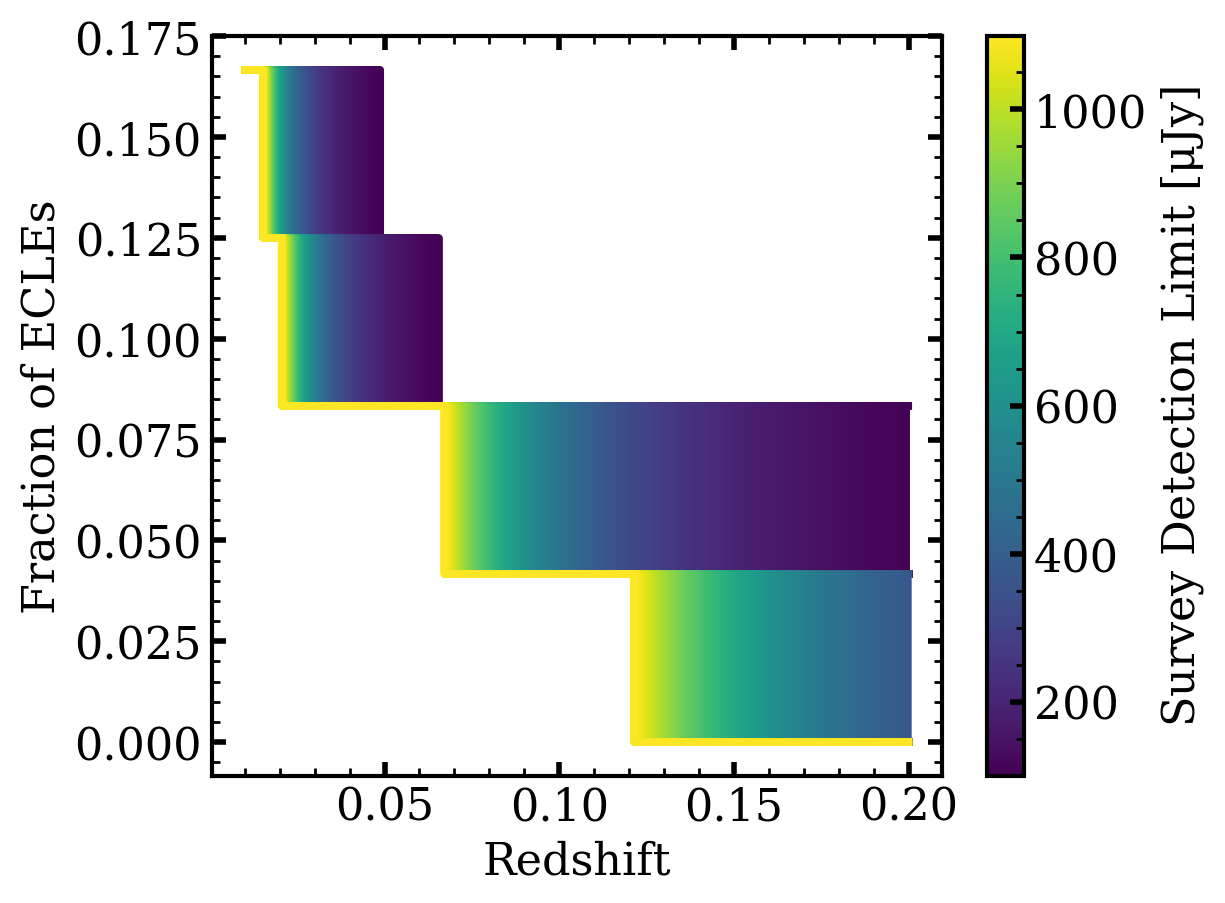

In [80]:
det_fluxes = np.array(res).T
z_test = np.linspace(0.01,0.2,10_000)
vlass_limit = np.arange(100, 1_100, 1)
norm = mpl.colors.Normalize(np.min(vlass_limit), np.max(vlass_limit))
cmap = plt.cm.viridis

fig, ax = plt.subplots()
for ii, vl in enumerate(vlass_limit):
    res = []
    for event, grp in sdets_sample.groupby("name"):
        z_og = db.get_meta(names=event, query_private=True)[0].get_redshift()
        res.append(lum_at_z(grp.converted_flux.max()*u.mJy, z_og, z_test=z_test).value)
    det_fluxes = np.array(res).T
    
    n_dets = np.sum(det_fluxes > vl, axis=1)
    frac = n_dets/24
    ax.step(z_test, frac, color=cmap(norm(vl)))
    
ax.set_ylabel("Fraction of ECLEs")
ax.set_xlabel("Redshift")

sm = mpl.cm.ScalarMappable(
    norm=norm, 
    cmap=cmap
)
fig.colorbar(sm, ax=ax, label=r"Survey Detection Limit [$\mu$Jy]")

In [71]:
vlass_limit

array([ 100.        ,  101.001001  ,  102.002002  ,  103.003003  ,
        104.004004  ,  105.00500501,  106.00600601,  107.00700701,
        108.00800801,  109.00900901,  110.01001001,  111.01101101,
        112.01201201,  113.01301301,  114.01401401,  115.01501502,
        116.01601602,  117.01701702,  118.01801802,  119.01901902,
        120.02002002,  121.02102102,  122.02202202,  123.02302302,
        124.02402402,  125.02502503,  126.02602603,  127.02702703,
        128.02802803,  129.02902903,  130.03003003,  131.03103103,
        132.03203203,  133.03303303,  134.03403403,  135.03503504,
        136.03603604,  137.03703704,  138.03803804,  139.03903904,
        140.04004004,  141.04104104,  142.04204204,  143.04304304,
        144.04404404,  145.04504505,  146.04604605,  147.04704705,
        148.04804805,  149.04904905,  150.05005005,  151.05105105,
        152.05205205,  153.05305305,  154.05405405,  155.05505506,
        156.05605606,  157.05705706,  158.05805806,  159.05905